In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
csv_path = r"C:\Users\HP\Desktop\assignment-2\archive\Data.csv"


df = pd.read_csv(csv_path, nrows=1000000)

print("Shape:", df.shape)

Shape: (1000000, 57)


In [7]:
print(df["label"].value_counts(dropna=False))

label
0.0     280000
11.0     36000
19.0     36000
18.0     36000
17.0     36000
16.0     36000
15.0     36000
14.0     36000
13.0     36000
12.0     36000
10.0     36000
1.0      36000
9.0      36000
8.0      36000
7.0      36000
6.0      36000
5.0      36000
4.0      36000
3.0      36000
2.0      36000
20.0     36000
Name: count, dtype: int64


In [8]:
sensor_cols = [c for c in df.columns if c.startswith("xmeas")]
print("Number of sensor columns:", len(sensor_cols))

data = df[sensor_cols].copy()
data.head()

Number of sensor columns: 41


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41
0,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,74.863,120.41,0.33818,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
1,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,75.000,120.41,0.33620,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
2,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,74.771,120.42,0.33563,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
3,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,75.224,120.39,0.33553,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
4,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,75.388,120.39,0.32632,...,1.0938,18.666,2.2193,4.8304,2.2416,0.017866,0.8357,0.098577,53.724,43.828


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.values)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (1000000, 41)


In [10]:
X_train, X_val = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (800000, 41)
X_val shape: (200000, 41)


In [12]:
# Latent dimension
latent_dim = 8
input_dim = X_train.shape[1]

# Encoder
encoder_inputs = layers.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sampling layer
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,), name="z_sampling")
x = layers.Dense(32, activation="relu")(latent_inputs)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 41)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 64)                   2688      ['encoder_input[0][0]']       
                                                                                                  
 dense_1 (Dense)             (None, 32)                   2080      ['dense[0][0]']               
                                                                                                  
 z_mean (Dense)              (None, 8)                    264       ['dense_1[0][0]']             
                                                                                           

In [13]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(data - reconstruction), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = vae.fit(
    X_train,
    validation_data=(X_val,),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
6250/6250 [==============================] - 35s 5ms/step - loss: 18.9763 - reconstruction_loss: 15.6521 - kl_loss: 3.3242 - val_loss: 17.9531 - val_reconstruction_loss: 14.0122 - val_kl_loss: 3.9410
Epoch 2/30
6250/6250 [==============================] - 37s 6ms/step - loss: 16.9512 - reconstruction_loss: 13.1693 - kl_loss: 3.7819 - val_loss: 17.1167 - val_reconstruction_loss: 12.9087 - val_kl_loss: 4.2080
Epoch 3/30
6250/6250 [==============================] - 32s 5ms/step - loss: 16.5913 - reconstruction_loss: 12.6279 - kl_loss: 3.9634 - val_loss: 17.2523 - val_reconstruction_loss: 12.8745 - val_kl_loss: 4.3778
Epoch 4/30
6250/6250 [==============================] - 32s 5ms/step - loss: 16.4536 - reconstruction_loss: 12.4575 - kl_loss: 3.9961 - val_loss: 17.1581 - val_reconstruction_loss: 12.8760 - val_kl_loss: 4.2821
Epoch 5/30
6250/6250 [==============================] - 26s 4ms/step - loss: 16.3763 - reconstruction_loss: 12.3667 - kl_loss: 4.0096 - val_loss: 16.6968 - 

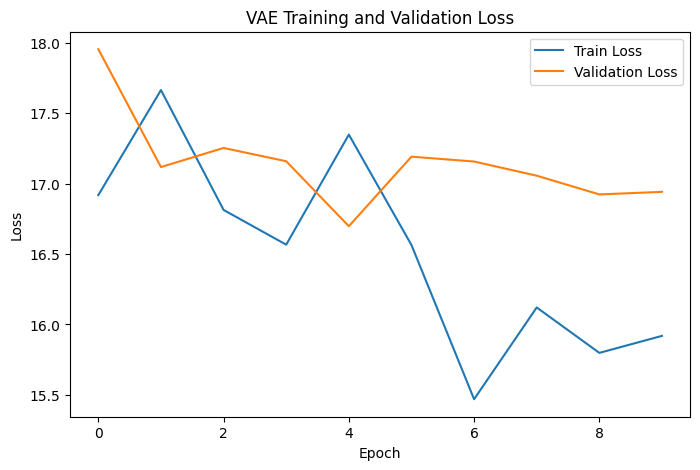

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("VAE Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
z_mean_val, z_log_var_val, z_val = encoder.predict(X_val)
X_val_recon = decoder.predict(z_val)

val_mse = np.mean(np.square(X_val - X_val_recon), axis=1)

print("Mean Reconstruction Error:", val_mse.mean())
print("Standard Deviation:", val_mse.std())
print("Maximum Reconstruction Error:", val_mse.max())

6250/6250 [==============================] - 11s 2ms/step
Mean Reconstruction Error: 0.3027054241784336
Standard Deviation: 0.14518453502884163
Maximum Reconstruction Error: 3.321620165045305


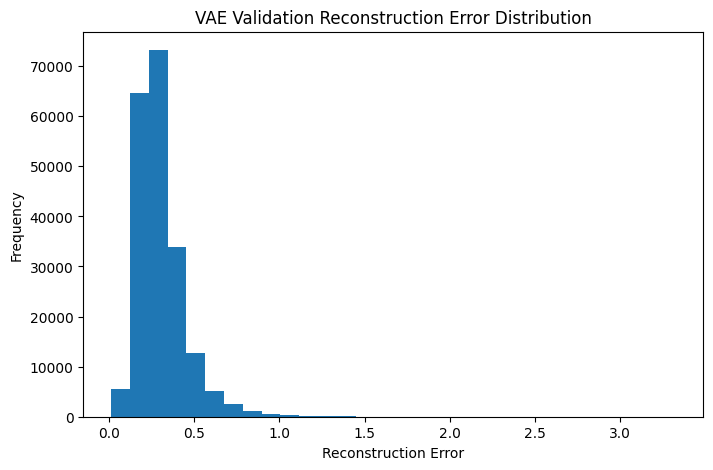

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(val_mse, bins=30)
plt.title("VAE Validation Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [20]:
threshold = val_mse.mean() + 3 * val_mse.std()
print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.7382590292649585


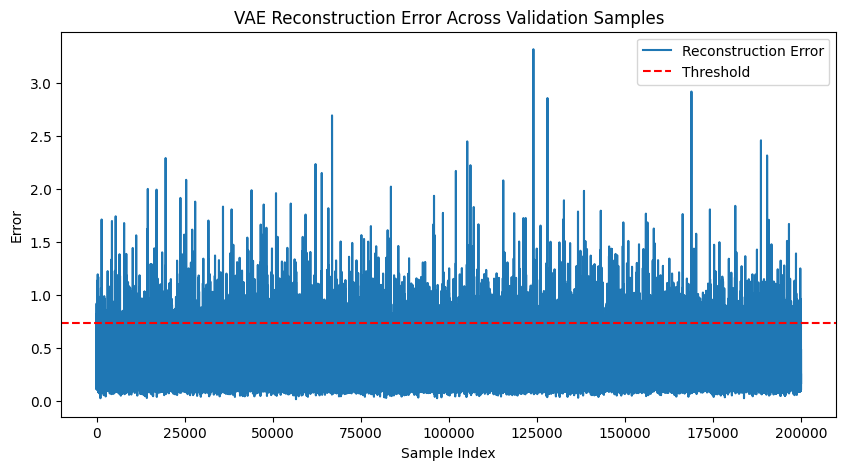

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(val_mse, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("VAE Reconstruction Error Across Validation Samples")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [22]:
anomaly_flags = val_mse > threshold

print("Potential anomalies found:", anomaly_flags.sum())
print("Total validation samples:", len(anomaly_flags))
print("Percentage flagged:", (anomaly_flags.sum() / len(anomaly_flags)) * 100, "%")

Potential anomalies found: 3332
Total validation samples: 200000
Percentage flagged: 1.6660000000000001 %


In [23]:
encoder.save("train2_vae_encoder.keras")
decoder.save("train2_vae_decoder.keras")
joblib.dump(scaler, "train2_scaler_te.pkl")

print("VAE encoder, decoder, and scaler saved successfully.")

VAE encoder, decoder, and scaler saved successfully.
